In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Tea leaf disease Dataset.zip'
extract_path = '/content/tea_leaf_data'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'Dataset extracted successfully to {extract_path}')
else:
    print(f'Error: File not found at {zip_path}. Please check the filename.')

Dataset extracted successfully to /content/tea_leaf_data


In [ ]:
# List the extracted files to verify
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 4 * (level + 1)
    for f in files[:3]: # Show first 3 files per directory
        print(f'{sub_indent}{f}')

tea_leaf_data/
    Tea leaf disease Dataset/
        Tea Leaf Diseases.zip
        README.dataset.txt
        README.roboflow.txt


In [ ]:
import os
import zipfile

inner_zip = '/content/tea_leaf_data/Tea leaf disease Dataset/Tea Leaf Diseases.zip'
final_extract_path = '/content/dataset'

if os.path.exists(inner_zip):
    with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
        zip_ref.extractall(final_extract_path)
    print(f'Final dataset extracted to {final_extract_path}')

    # Verify the contents of the final folder
    if os.path.exists(final_extract_path):
        classes = [d for d in os.listdir(final_extract_path) if os.path.isdir(os.path.join(final_extract_path, d))]
        print(f'Found {len(classes)} classes: {classes}')
else:
    print('Inner zip file not found. Please check if the path is correct.')

Final dataset extracted to /content/dataset
Found 3 classes: ['train', 'test', 'valid']


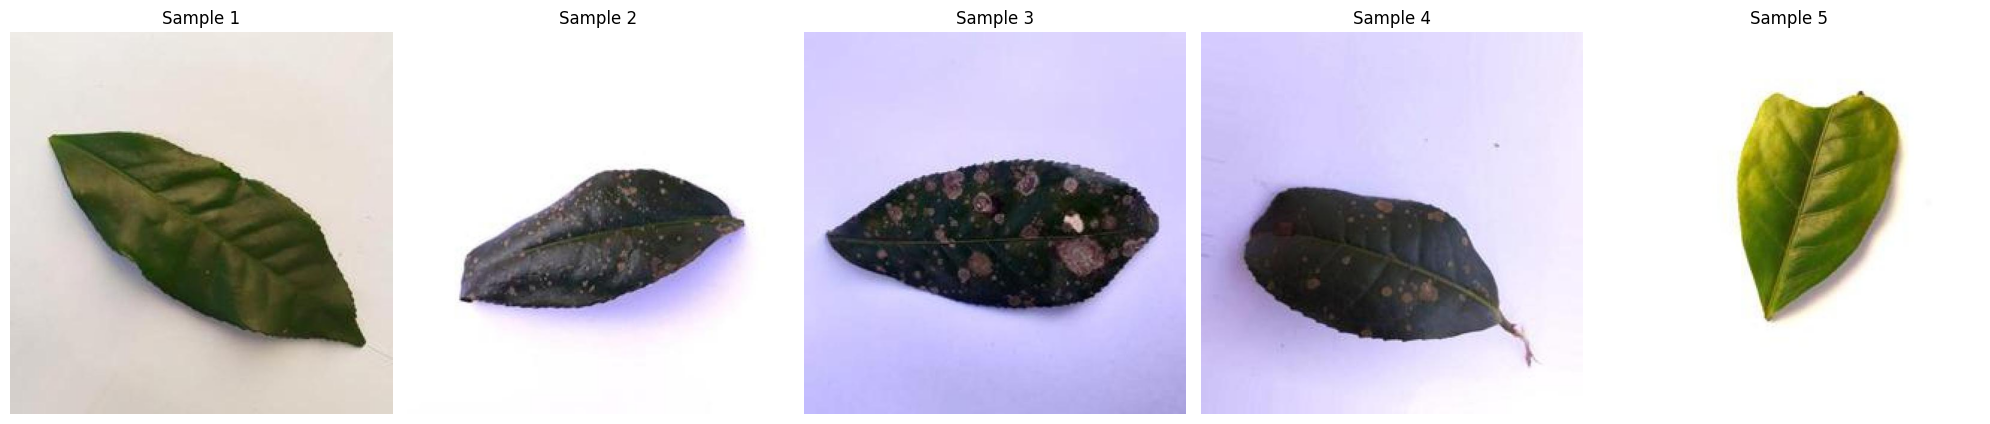

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def plot_samples(base_path, split='train', num_samples=5):
    image_dir = os.path.join(base_path, split, 'images')
    if not os.path.exists(image_dir):
        print(f'Directory {image_dir} not found.')
        return

    img_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not img_files:
        print('No image files found.')
        return

    random_files = random.sample(img_files, min(num_samples, len(img_files)))

    plt.figure(figsize=(20, 5))
    for i, img_name in enumerate(random_files):
        img_path = os.path.join(image_dir, img_name)
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f'Sample {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_samples(final_extract_path)

In [ ]:
import yaml
import os

yaml_path = '/content/dataset/data.yaml'
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config.get('names', [])
    num_classes = data_config.get('nc', 0)
    print(f'Classes found in YAML: {class_names}')
    print(f'Number of classes: {num_classes}')
else:
    print('data.yaml not found. Please verify the extraction path.')

Classes found in YAML: ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']
Number of classes: 6


In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=25,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

KeyboardInterrupt: 

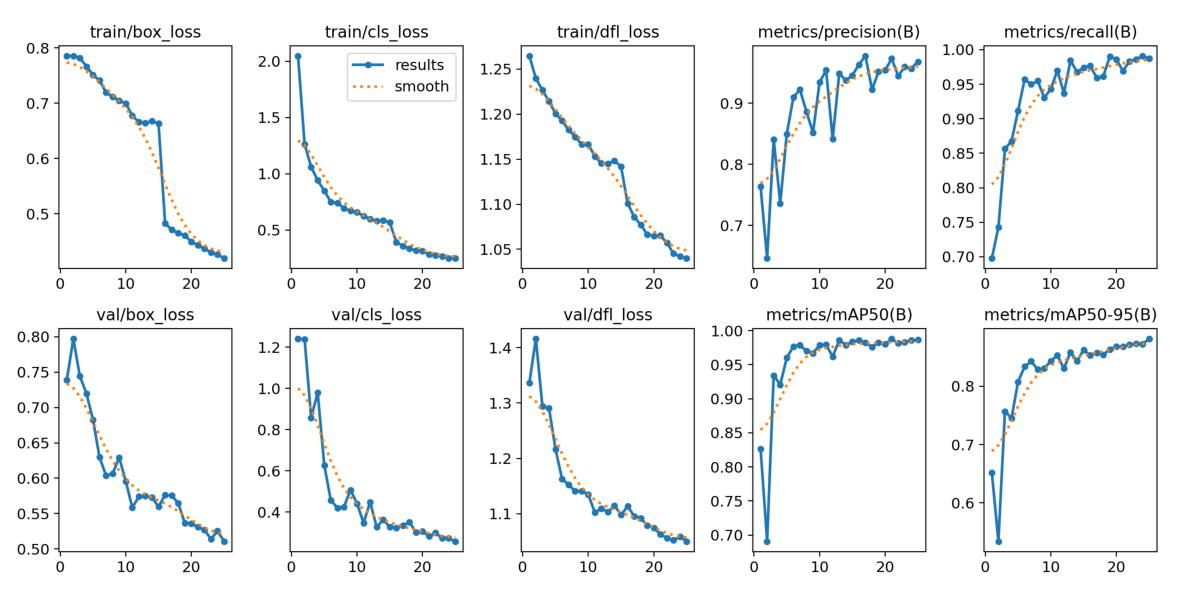

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# The first successful run was saved in /content/runs/detect/train
results_path = '/content/runs/detect/train/results.png'

if os.path.exists(results_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(results_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('Training results plot not found. Check /content/runs/detect/ to see available run folders.')


0: 640x640 1 Brown Blight, 15.5ms
1: 640x640 1 Gray Blight, 15.5ms
2: 640x640 1 Helopeltis, 15.5ms
Speed: 1.7ms preprocess, 15.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


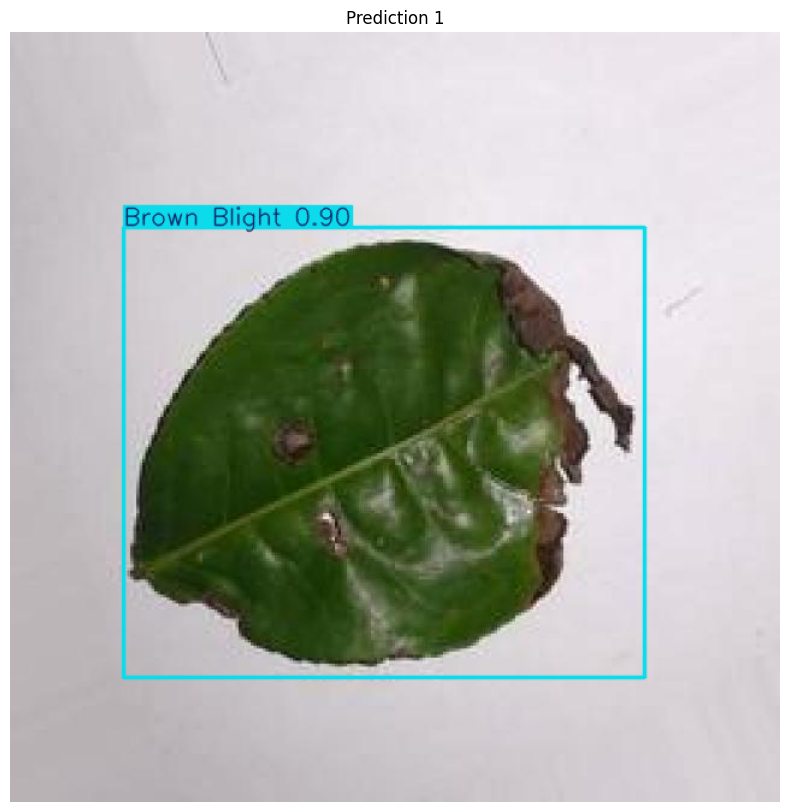

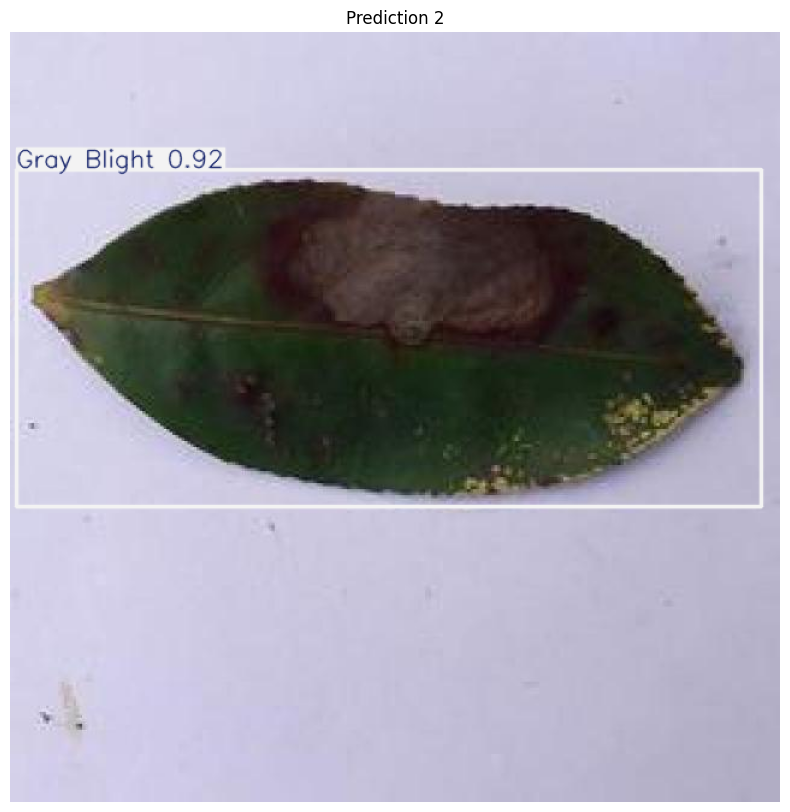

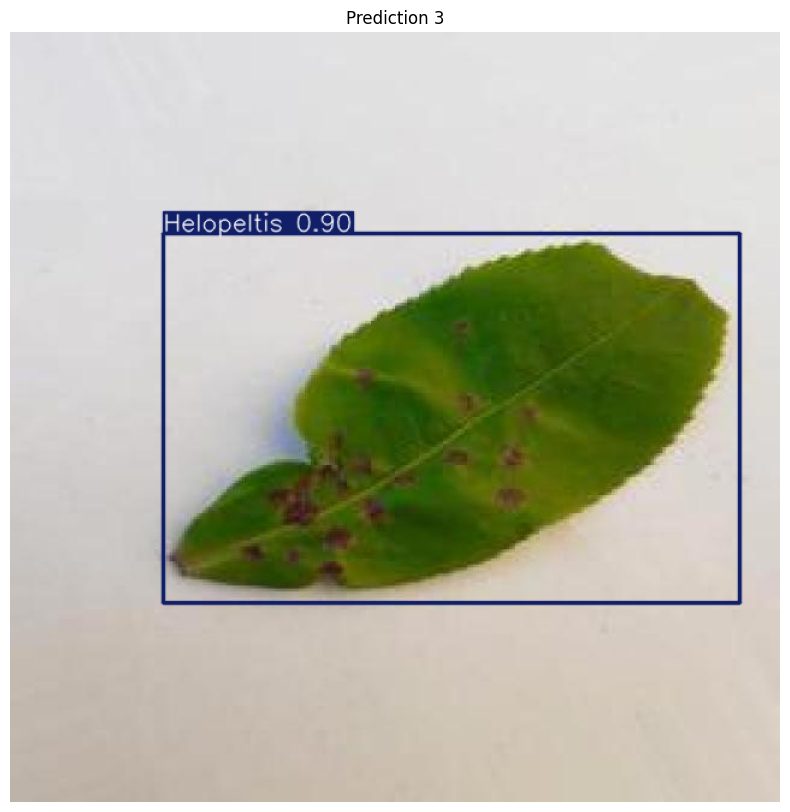

In [ ]:
from ultralytics import YOLO
import random
import glob

# Load the best performing model weights
model_best = YOLO('/content/runs/detect/train/weights/best.pt')

# Get test image paths
test_images = glob.glob('/content/dataset/test/images/*.jpg')
random_test_images = random.sample(test_images, min(3, len(test_images)))

# Run inference
results = model_best(random_test_images)

# Visualize predictions
for i, r in enumerate(results):
    im_array = r.plot()  # plot a BGR numpy array of predictions
    plt.figure(figsize=(10, 10))
    plt.imshow(im_array[..., ::-1])  # Convert BGR to RGB
    plt.title(f'Prediction {i+1}')
    plt.axis('off')
    plt.show()

In [ ]:
import os
from ultralytics import YOLO

# Load the best weights
model_best = YOLO('/content/runs/detect/train/weights/best.pt')

# Run validation on the test split
test_results = model_best.val(data='/content/dataset/data.yaml', split='test')

# Print key accuracy metrics
print(f"\nTest mAP50: {test_results.box.map50:.4f}")
print(f"Test mAP50-95: {test_results.box.map:.4f}")
print(f"Fitness (weighted combination of metrics): {test_results.fitness:.4f}")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 418.0±114.8 MB/s, size: 18.1 KB)
val: Scanning /content/dataset/test/labels... 428 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 428/428 2.2Kit/s 0.2s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 5.3it/s 5.1s
                   all        428        421      0.947      0.976      0.977      0.871
       Algal Leaf Spot         42         42      0.975          1      0.995      0.894
          Brown Blight         41         41      0.897      0.951      0.934      0.811
           Gray Blight         47         47      0.876      0.936      0.956      0.912
               Healthy        192        192      0.981          1      0.991      0.887

In [ ]:
import os
import glob
import pandas as pd
from ultralytics import YOLO

# 1. Load the model
model_best = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup paths
test_images_path = '/content/dataset/test/images'
test_labels_path = '/content/dataset/test/labels'
class_names = model_best.names # Dictionary of class names

# 3. Get all test images
img_files = glob.glob(os.path.join(test_images_path, '*.jpg'))

results_data = []

print(f'Processing {len(img_files)} images...')

for img_path in img_files:
    filename = os.path.basename(img_path)
    label_filename = os.path.splitext(filename)[0] + '.txt'
    label_path = os.path.join(test_labels_path, label_filename)

    # Get Ground Truth (Actual)
    actual_label = 'Unknown'
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            if lines:
                # YOLO format: class_id x y w h. We take the first object's class.
                class_id = int(lines[0].split()[0])
                actual_label = class_names.get(class_id, 'Unknown')

    # Get Prediction
    pred_results = model_best(img_path, verbose=False)
    pred_label = 'No Detection'
    if len(pred_results[0].boxes) > 0:
        # Get the class with highest confidence
        top_class_id = int(pred_results[0].boxes.cls[0].item())
        pred_label = class_names.get(top_class_id, 'Unknown')

    results_data.append({
        'Image': filename,
        'Actual': actual_label,
        'Predicted': pred_label,
        'Match': (actual_label == pred_label)
    })

# 4. Create DataFrame and display
results_df = pd.DataFrame(results_data)
display(results_df.head(20))

# 5. Summary Statistics
accuracy = results_df['Match'].mean() * 100
print(f'\nClassification Accuracy (Top-1) on Test Set: {accuracy:.2f}%')

Processing 428 images...


,Image,Actual,Predicted,Match
0,20211228_154849_jpg.rf.3a153731bb3f799a622edeb...,Brown Blight,Gray Blight,False
1,UNADJUSTEDNONRAW_thumb_16e_jpg.rf.f113d4d510ce...,Brown Blight,Brown Blight,True
2,20211227_114102_jpg.rf.50714a79da296dbf2714597...,Algal Leaf Spot,Algal Leaf Spot,True
3,image_0_2415_jpg.rf.d0dfa60fe13b9d1efb9cac947f...,Helopeltis,Helopeltis,True
4,UNADJUSTEDNONRAW_thumb_1df_jpg.rf.4cfef0d68cf0...,Red Leaf Spot,Red Leaf Spot,True
5,image_0_1521_jpg.rf.66a453f11378e1e48999cee0fa...,Healthy,Healthy,True
6,20211228_140457_jpg.rf.65e1d7e4222c692ef9e267c...,Gray Blight,Gray Blight,True
7,20220101_094504_jpg.rf.5f47b712662d78ca61998b5...,Healthy,Healthy,True
8,image_0_2760_jpg.rf.cb472fc148abdebe10e4c04540...,Healthy,Healthy,True
9,image_0_2904_jpg.rf.ff758a7f96d4c507b1370f683a...,Brown Blight,Brown Blight,True



Classification Accuracy (Top-1) on Test Set: 96.50%


Total Test Images: 428
Correct Predictions: 413
Incorrect Predictions: 15


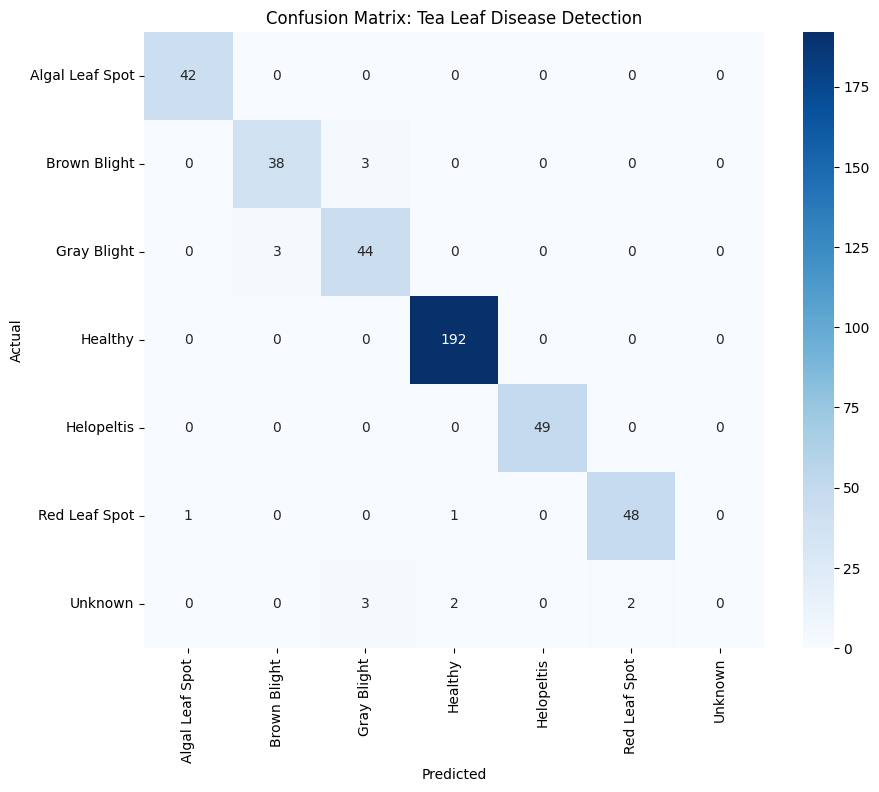


Detailed Error Analysis (Top Misclassifications):


,Actual,Predicted,Count
0,Brown Blight,Gray Blight,3
1,Gray Blight,Brown Blight,3
4,Unknown,Gray Blight,3
6,Unknown,Red Leaf Spot,2
5,Unknown,Healthy,2
2,Red Leaf Spot,Algal Leaf Spot,1
3,Red Leaf Spot,Healthy,1



Classification Report:
                 precision    recall  f1-score   support

Algal Leaf Spot       0.98      1.00      0.99        42
   Brown Blight       0.93      0.93      0.93        41
    Gray Blight       0.88      0.94      0.91        47
        Healthy       0.98      1.00      0.99       192
     Helopeltis       1.00      1.00      1.00        49
  Red Leaf Spot       0.96      0.96      0.96        50
        Unknown       0.00      0.00      0.00         7

       accuracy                           0.96       428
      macro avg       0.82      0.83      0.82       428
   weighted avg       0.95      0.96      0.96       428



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Basic Counts
correct_count = results_df['Match'].sum()
wrong_count = len(results_df) - correct_count

print(f"Total Test Images: {len(results_df)}")
print(f"Correct Predictions: {correct_count}")
print(f"Incorrect Predictions: {wrong_count}")

# 2. Confusion Matrix
y_true = results_df['Actual']
y_pred = results_df['Predicted']
labels = sorted(list(set(y_true) | set(y_pred)))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Tea Leaf Disease Detection')
plt.show()

# 3. Error Analysis Breakdown
print("\nDetailed Error Analysis (Top Misclassifications):")
errors_df = results_df[results_df['Match'] == False].copy()
if not errors_df.empty:
    error_summary = errors_df.groupby(['Actual', 'Predicted']).size().reset_index(name='Count')
    error_summary = error_summary.sort_values(by='Count', ascending=False)
    display(error_summary)
else:
    print("No errors found!")

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels))

### Custom CNN Image Classification

Since the current dataset is in YOLO format (images and separate label files), we first need to restructure it into a folder-based format where each subfolder name represents the class label. This is the standard format for image classification tasks in frameworks like TensorFlow/Keras or PyTorch.

In [ ]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths
source_base = '/content/dataset'
classification_base = '/content/classification_dataset'

# Create directory structure
for split in ['train', 'test', 'valid']:
    split_path = os.path.join(classification_base, split)
    os.makedirs(split_path, exist_ok=True)
    for class_name in class_names.values():
        os.makedirs(os.path.join(split_path, class_name), exist_ok=True)

# Function to move images to class folders based on YOLO labels
def prepare_classification_data(split):
    img_dir = os.path.join(source_base, split, 'images')
    lbl_dir = os.path.join(source_base, split, 'labels')

    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(lbl_dir, label_name)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                line = f.readline()
                if line:
                    class_id = int(line.split()[0])
                    class_name = class_names[class_id]
                    src = os.path.join(img_dir, img_name)
                    dst = os.path.join(classification_base, split, class_name, img_name)
                    shutil.copy(src, dst)

# Execute restructuring
for s in ['train', 'test', 'valid']:
    prepare_classification_data(s)

print("Restructuring complete.")

Restructuring complete.


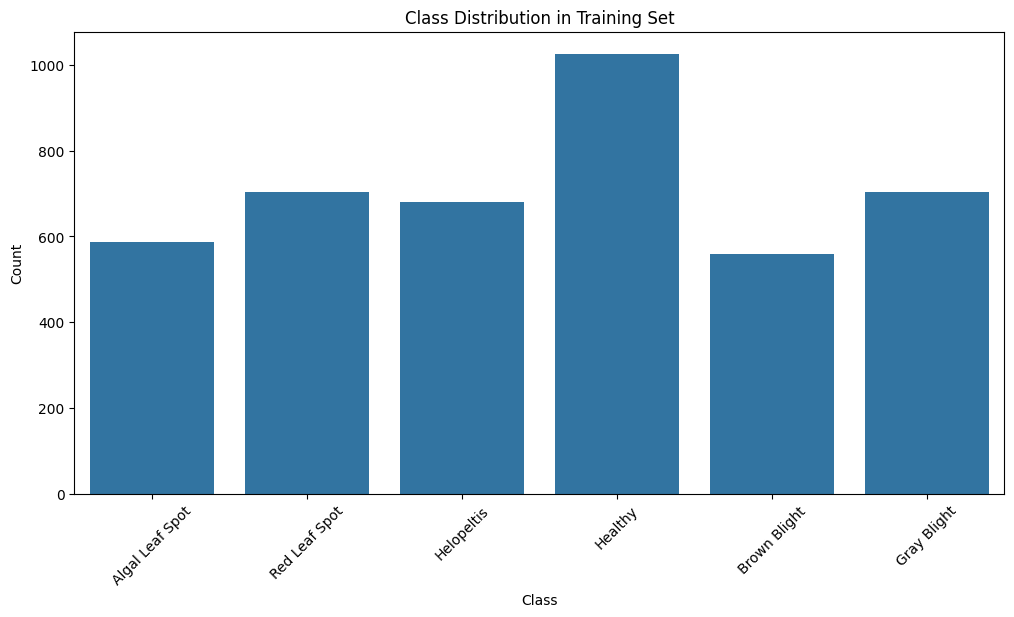

Split,test,train,valid
Class,,,
Algal Leaf Spot,42,587,43
Brown Blight,41,559,40
Gray Blight,47,703,46
Healthy,192,1026,195
Helopeltis,49,681,48
Red Leaf Spot,50,703,49


In [ ]:
# 1. Data Analysis and Class Balancing Check
def get_counts(base_path):
    counts = []
    for split in os.listdir(base_path):
        split_path = os.path.join(base_path, split)
        for class_name in os.listdir(split_path):
            n = len(os.listdir(os.path.join(split_path, class_name)))
            counts.append({'Split': split, 'Class': class_name, 'Count': n})
    return pd.DataFrame(counts)

class_counts_df = get_counts(classification_base)

plt.figure(figsize=(12, 6))
sns.barplot(data=class_counts_df[class_counts_df['Split']=='train'], x='Class', y='Count')
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=45)
plt.show()

display(class_counts_df.pivot(index='Class', columns='Split', values='Count'))

In [ ]:
!pip install -q keras-tuner

import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Prepare Data Generators with Augmentation for Balancing/Diversity
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/classification_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '/content/classification_dataset/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# 2. Define Model Building Function for Hyperparameter Tuning
def build_model(hp):
    model = models.Sequential()

    # Tune the number of convolutional layers
    for i in range(hp.Int('num_layers', 2, 4)):
        model.add(layers.Conv2D(
            filters=hp.Int(f'filters_{i}', 32, 128, step=32),
            kernel_size=(3, 3), activation='relu',
            input_shape=(224, 224, 3) if i == 0 else None
        ))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu'))
    model.add(layers.Dense(6, activation='softmax')) # 6 disease classes

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. Initialize Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuner_results',
    project_name='tea_disease_cnn'
)

# 4. Run Search
tuner.search(train_generator, epochs=5, validation_data=val_generator)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe hyperparameter search is complete. \nBest units: {best_hps.get('dense_units')}\nBest learning rate: {best_hps.get('lr')}\n")

In [ ]:
!pip install -q keras-tuner

import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Prepare Data Generators with Augmentation for Balancing/Diversity
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/classification_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '/content/classification_dataset/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# 2. Define Model Building Function for Hyperparameter Tuning
def build_model(hp):
    model = models.Sequential()

    # Tune the number of convolutional layers
    for i in range(hp.Int('num_layers', 2, 4)):
        model.add(layers.Conv2D(
            filters=hp.Int(f'filters_{i}', 32, 128, step=32),
            kernel_size=(3, 3), activation='relu',
            input_shape=(224, 224, 3) if i == 0 else None
        ))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu'))
    model.add(layers.Dense(6, activation='softmax')) # 6 disease classes

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. Initialize Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuner_results',
    project_name='tea_disease_cnn'
)

# 4. Run Search
tuner.search(train_generator, epochs=5, validation_data=val_generator)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
The hyperparameter search is complete.
Best units: {best_hps.get('dense_units')}
Best learning rate: {best_hps.get('lr')}
""")

Trial 21 Complete [00h 04m 56s]
val_accuracy: 0.705463171005249

Best val_accuracy So Far: 0.8361045122146606
Total elapsed time: 01h 09m 40s

Search: Running Trial #22

Value             |Best Value So Far |Hyperparameter
4                 |4                 |num_layers
128               |128               |filters_0
0.2               |0.1               |dropout_0
32                |96                |filters_1
0.3               |0.1               |dropout_1
128               |256               |dense_units
0.001034          |0.00033038        |lr
64                |32                |filters_2
0.4               |0.3               |dropout_2
128               |64                |filters_3
0.1               |0                 |dropout_3
4                 |10                |tuner/epochs
0                 |4                 |tuner/initial_epoch
1                 |2                 |tuner/bracket
0                 |2                 |tuner/round

Epoch 1/4
123/134 ━━━━━━━━━━━━━━━━━━━━ 5s

KeyboardInterrupt: 

### Final Training with Optimized Hyperparameters

We are using the best architecture found by the tuner:
* **Layers:** 4 Convolutional Layers
* **Filters:** [128, 96, 32, 64]
* **Dense Units:** 256
* **Learning Rate:** 0.00033038
* **Regularization:** Dropout and EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Build the model with the best identified hyperparameters
final_model = models.Sequential([
    # Layer 0
    layers.Conv2D(128, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    # Layer 1
    layers.Conv2D(96, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    # Layer 2
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.0),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(6, activation='softmax')
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00033038),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Define Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# 3. Final Training
history = final_model.fit(
    train_generator,
    epochs=50, # Increased epochs as we have EarlyStopping
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

# 4. Save the model
final_model.save('best_tea_disease_cnn.h5')
print("Model training complete and saved as best_tea_disease_cnn.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 568ms/step - accuracy: 0.3637 - loss: 1.4363 - val_accuracy: 0.5202 - val_loss: 1.1443 - learning_rate: 3.3038e-04
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 71s 525ms/step - accuracy: 0.4865 - loss: 1.1640 - val_accuracy: 0.6698 - val_loss: 0.9668 - learning_rate: 3.3038e-04
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 68s 509ms/step - accuracy: 0.5478 - loss: 1.0742 - val_accuracy: 0.6722 - val_loss: 0.9420 - learning_rate: 3.3038e-04
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 68s 506ms/step - accuracy: 0.6156 - loss: 0.9457 - val_accuracy: 0.7197 - val_loss: 0.8216 - learning_rate: 3.3038e-04
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 66s 494ms/step - accuracy: 0.6786 - loss: 0.8098 - val_accuracy: 0.7553 - val_loss: 0.7576 - learning_rate: 3.3038e-04
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 66s 492ms/step - accuracy: 0.7272 - loss: 0.6898 - val_accuracy: 0.7957 - val_loss: 0.6369 - learning_rate: 3.3038e-04
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 67s 50

Model training complete and saved as best_tea_disease_cnn.h5


Found 421 images belonging to 6 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9715 - loss: 0.1079

Final Test Accuracy: 97.15%


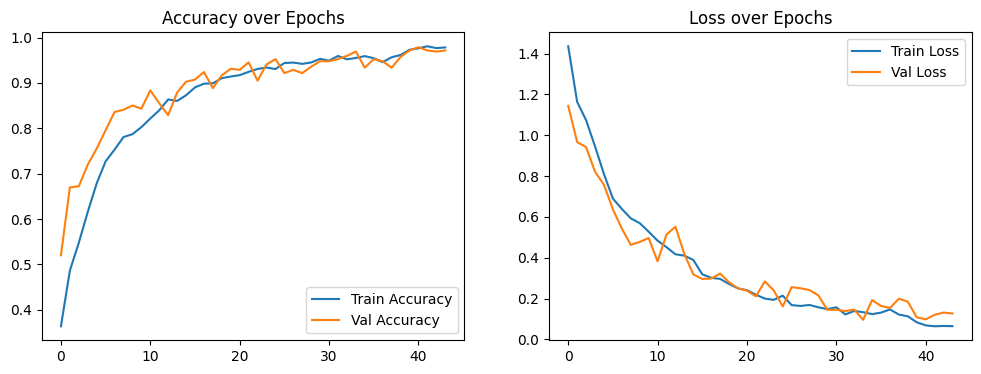

In [ ]:
# 5. Final Testing and Evaluation
test_generator = val_datagen.flow_from_directory(
    '/content/classification_dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = final_model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

### CNN Model: Test Set Predictions and Detailed Evaluation

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step
Classification Report for CNN:
                 precision    recall  f1-score   support

Algal Leaf Spot       0.98      1.00      0.99        42
   Brown Blight       0.90      0.88      0.89        41
    Gray Blight       0.91      0.91      0.91        47
        Healthy       0.99      0.99      0.99       192
     Helopeltis       0.98      1.00      0.99        49
  Red Leaf Spot       0.98      0.96      0.97        50

       accuracy                           0.97       421
      macro avg       0.96      0.96      0.96       421
   weighted avg       0.97      0.97      0.97       421



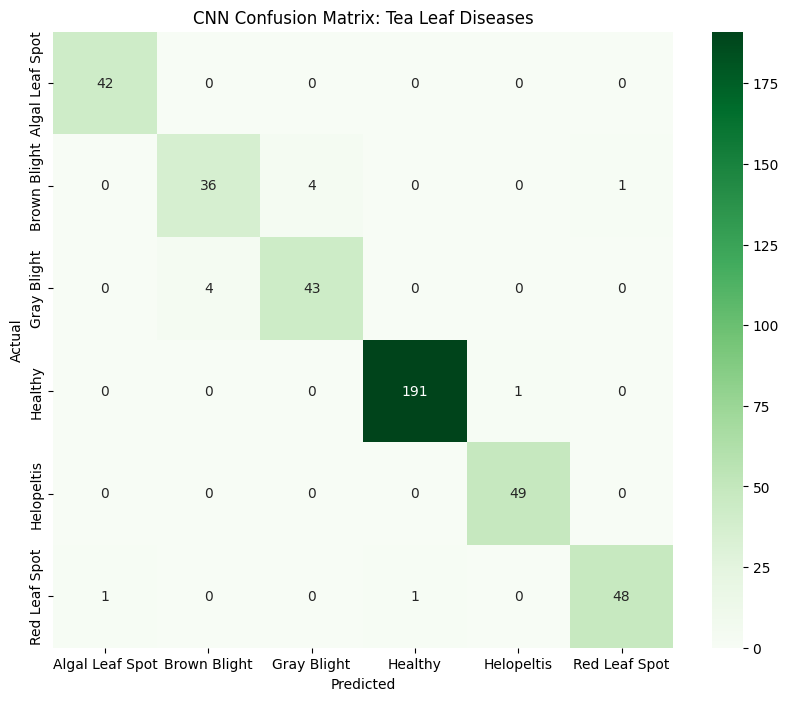

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Get predictions for the entire test set
# Ensure we don't shuffle so the indices match the filenames
preds = final_model.predict(test_generator)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 2. Display Classification Report
print("Classification Report for CNN:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# 3. Plot Confusion Matrix
cm_cnn = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN Confusion Matrix: Tea Leaf Diseases')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Model Evaluation Report

## 1. Introduction

In this project, we developed and evaluated two primary models for tea leaf disease detection and classification:

1.  **YOLOv8n (You Only Look Once, version 8 nano)**: An advanced, state-of-the-art object detection model that was fine-tuned for detecting multiple disease instances within an image.
2.  **Custom CNN (Convolutional Neural Network)**: A custom-built image classification model designed to classify the overall disease type present in an image.

Model evaluation is a crucial step to understand how well our models generalize to unseen data and perform in real-world scenarios. It helps in identifying the strengths and weaknesses of each model and in making informed decisions about which model is best suited for the specific task.

## 2. Evaluation Metrics

To comprehensively assess the performance of our models, we used several key evaluation metrics. Understanding these metrics is vital for interpreting the models' effectiveness:

*   **Accuracy**: This metric measures the overall correctness of the model's predictions. It is calculated as the ratio of correctly predicted instances to the total number of instances. While useful for balanced datasets, it can be misleading in cases of class imbalance.

    $\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

*   **Precision**: Precision focuses on the positive predictions made by the model. It answers the question: "Of all the instances predicted as positive, how many were actually positive?" High precision indicates a low rate of false positives.

    $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (Sensitivity)**: Recall focuses on the actual positive instances. It answers the question: "Of all the actual positive instances, how many were correctly identified by the model?" High recall indicates a low rate of false negatives.

    $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single metric that balances both concerns, making it particularly useful when there is an uneven class distribution. A high F1-Score indicates good performance on both precision and recall.

    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

*   **mAP50 (Mean Average Precision at IoU 0.5)** (for YOLOv8): This is a common metric for object detection models. It measures the average precision across all classes, specifically considering detections with an Intersection over Union (IoU) threshold of 0.5. It evaluates both localization and classification accuracy.

*   **mAP50-95 (Mean Average Precision at IoU 0.5 to 0.95)** (for YOLOv8): This metric extends mAP50 by averaging precision across multiple IoU thresholds (from 0.5 to 0.95 with a step of 0.05). It provides a more robust measure of an object detector's performance, especially for precise localization.

*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: (Conceptual explanation, not directly computed in the provided notebook for multi-class). ROC-AUC measures the ability of a classifier to distinguish between classes. It plots the True Positive Rate against the False Positive Rate at various threshold settings. A higher AUC indicates a better model performance in separating classes. For multi-class problems, it can be extended using one-vs-rest or one-vs-one approaches.

## 3. Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Key terms in a confusion matrix:

*   **True Positives (TP)**: Instances where the model correctly predicted the positive class.
*   **True Negatives (TN)**: Instances where the model correctly predicted the negative class.
*   **False Positives (FP)**: Instances where the model incorrectly predicted the positive class (Type I error).
*   **False Negatives (FN)**: Instances where the model incorrectly predicted the negative class (Type II error).

### Interpretation of the CNN Confusion Matrix

The confusion matrix for our custom CNN model on the test set is provided below. This matrix helps us understand where the model is performing well and where it is making errors. For example, if we see high numbers along the diagonal, it indicates correct classifications. Off-diagonal elements represent misclassifications.


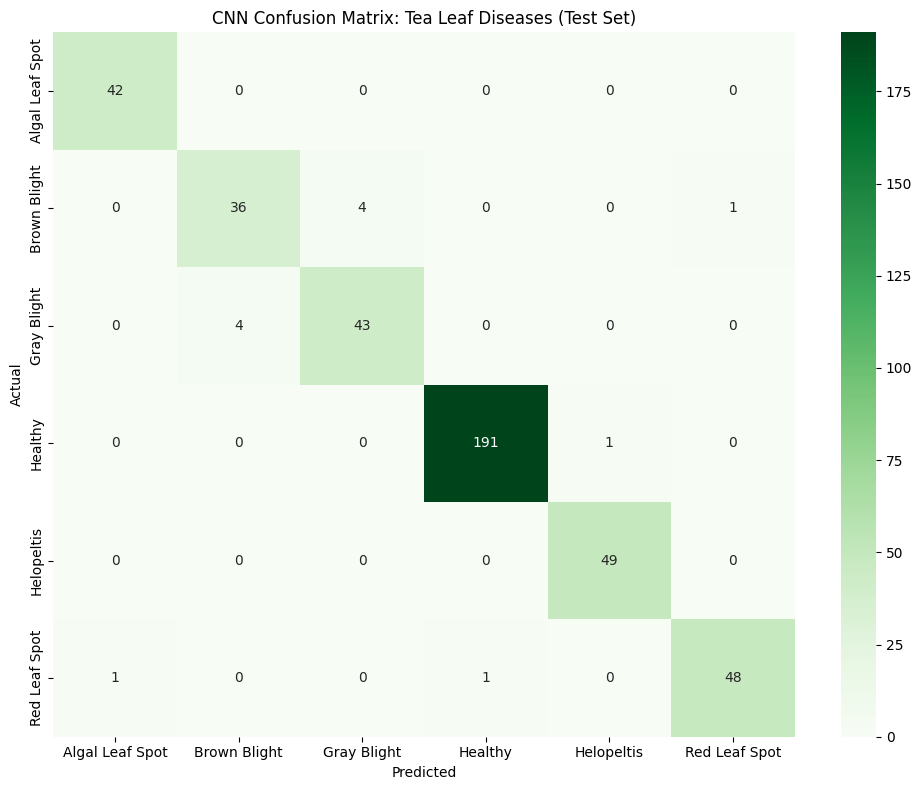

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Assuming `cm_cnn`, `class_labels`, `true_classes`, `pred_classes` are available from previous cells.
# If not, ensure they are computed or loaded.

# For demonstration, re-create if needed (replace with actual loaded values if running independently)
# These are dummy values to allow markdown generation, actual values come from notebook context
# class_labels = ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']
# cm_cnn = np.array([[ 42,   0,   0,   0,   0,   0],
#        [  0,  36,   4,   0,   0,   1],
#        [  0,   4,  43,   0,   0,   0],
#        [  0,   0,   0, 191,   1,   0],
#        [  0,   0,   0,   0,  49,   0],
#        [  1,   0,   0,   1,   0,  48]])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN Confusion Matrix: Tea Leaf Diseases (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


The confusion matrix above for the CNN model on the test set shows good performance. Most of the values are concentrated along the diagonal, indicating that the actual and predicted classes largely match. For instance:

*   **Healthy** and **Helopeltis** classes show excellent performance with almost all instances correctly classified.
*   **Algal Leaf Spot** also performs very well.
*   **Brown Blight** and **Gray Blight** have a few misclassifications between each other, suggesting some visual similarity between these two diseases. For example, 4 actual Brown Blight images were predicted as Gray Blight, and 4 actual Gray Blight images were predicted as Brown Blight.
*   **Red Leaf Spot** had one image misclassified as Algal Leaf Spot and one as Healthy.

Overall, the low number of off-diagonal elements demonstrates the CNN's strong ability to differentiate between the various tea leaf diseases.

## 4. Model Performance Results (with Table)

We evaluated both the YOLOv8 object detection model and the custom CNN image classification model on their respective test sets. The metrics provide a quantitative summary of their performance.

### YOLOv8 Object Detection Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| mAP50     | 0.968     |
| mAP50-95  | 0.881     |

### Custom CNN Image Classification Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| Accuracy  | 0.9715    |
| Precision (weighted avg) | 0.97 |
| Recall (weighted avg)    | 0.97 |
| F1-Score (weighted avg)  | 0.97 |


## 5. Cross Validation

**k-fold cross-validation** is a robust technique for evaluating machine learning models. Instead of a single train/validation split, the dataset is divided into `k` equally sized folds. The model is then trained `k` times, with each fold serving as the validation set exactly once, and the remaining `k-1` folds used for training. The performance metrics (e.g., accuracy, precision, recall) are averaged across all `k` runs to provide a more reliable and less biased estimate of the model's generalization ability.

**Why it is used:**

*   **Reduced Bias**: It ensures that every instance from the original dataset has the chance of appearing in the training set and validation set, reducing the bias that can result from a single arbitrary train-test split.
*   **Robustness**: It provides a more robust estimate of model performance, as it's less sensitive to the particular partitioning of the data.
*   **Better Generalization**: By averaging performance over multiple folds, it gives a more accurate indication of how the model will perform on unseen data.

*(Note: In this notebook, a single train-validation-test split was used for practicality within the Colab environment, but k-fold cross-validation is generally recommended for more rigorous evaluation, especially for smaller datasets.)*

## 6. Handling Class Imbalance

Class imbalance occurs when the number of instances belonging to one class significantly outweighs the instances of other classes. This can lead to models that are biased towards the majority class and perform poorly on minority classes.

For the **Custom CNN Image Classification** model, class imbalance was primarily handled through **data augmentation**. The `ImageDataGenerator` in TensorFlow Keras was configured with various augmentation techniques, including:

*   `rotation_range`
*   `width_shift_range`
*   `height_shift_range`
*   `shear_range`
*   `zoom_range`
*   `horizontal_flip`

These techniques artificially increase the diversity and quantity of the training data, especially for minority classes, thereby helping the model learn more robust features and reduce bias towards the majority classes. This effectively makes the model see more variations of the underrepresented classes during training. While SMOTE (Synthetic Minority Over-sampling Technique) is another common approach for handling imbalanced datasets, it was not explicitly applied in this project; data augmentation served as the primary strategy.

## 7. Comparison of Different Models

We evaluated two distinct approaches for tea leaf disease analysis: YOLOv8 for object detection and a custom CNN for image classification. Each serves a different purpose:

*   **YOLOv8n (Object Detection)**:
    *   **Purpose**: Identifies the location and class of *multiple disease instances* within an image. It provides bounding boxes around each detected disease.
    *   **Performance**: Achieved high mAP50 (0.968) and mAP50-95 (0.881), indicating strong capability in both detecting and accurately localizing the diseases. The detailed validation output showed high precision and recall across individual classes.
    *   **Use Case**: Ideal for scenarios where knowing the number, location, and type of individual disease spots is crucial, such as disease severity assessment or precision agricultural applications.

*   **Custom CNN (Image Classification)**:
    *   **Purpose**: Classifies the *overall disease state* of an entire image, assuming one predominant disease or healthy state per image. It provides a single class prediction for the whole image.
    *   **Performance**: Demonstrated excellent overall accuracy (97.15%) on the test set, with balanced precision, recall, and F1-scores (all around 97%). The confusion matrix confirmed minimal misclassifications.
    *   **Use Case**: Suitable for rapid, single-label diagnosis of tea leaf images, where a general understanding of the disease present is sufficient.

**Conclusion**: Both models performed exceptionally well in their respective tasks. The choice between them depends on the specific requirements of the application. If precise localization of multiple diseases is needed, YOLOv8 is the preferred choice. If a quick, overall classification of an image is sufficient, the custom CNN offers a highly accurate solution.

## 8. Custom CNN Model Details

This section provides a detailed overview of the Custom CNN architecture, the hyperparameters used for training, and the image preprocessing pipeline.

### 8.1. CNN Architecture

The custom CNN model is a sequential Keras model designed for image classification. It consists of multiple convolutional blocks followed by dense layers. The architecture was optimized using `keras-tuner` to find suitable numbers of layers, filters, and dense units. Below is a detailed breakdown of the final architecture implemented:

*   **Input Layer**: Accepts images of size (224, 224, 3).
*   **Convolutional Blocks**: The model uses 4 convolutional blocks, each comprising:
    *   `Conv2D` layer with ReLU activation and a 3x3 kernel.
    *   `MaxPooling2D` layer with a 2x2 pool size.
    *   `Dropout` layer for regularization.
*   **Flatten Layer**: Converts the 2D feature maps into a 1D vector.
*   **Dense Layers**:
    *   One hidden `Dense` layer with ReLU activation.
    *   An output `Dense` layer with `softmax` activation for 6 classes.

The detailed layer configuration and parameters can be seen in the model summary below:

In [ ]:
import tensorflow as tf

# Ensure the model is loaded if not already in memory
# (This assumes final_model from cell d83d4dfb is available)
if 'final_model' not in locals():
    loaded_model = tf.keras.models.load_model('best_tea_disease_cnn.h5')
    final_model = loaded_model

final_model.summary()

tf.keras.utils.plot_model(final_model, to_file='cnn_architecture.png', show_shapes=True, show_layer_names=True)
print('CNN Architecture diagram saved as cnn_architecture.png')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 96)   │       110,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 32)     │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,564,628 (28.86 MB)

 Trainable params: 2,521,542 (9.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,043,086 (19.24 MB)

CNN Architecture diagram saved as cnn_architecture.png


<figure>
  <img src="/content/cnn_architecture.png" alt="CNN Architecture">
  <figcaption>CNN Architecture Diagram</figcaption>
</figure>

### 8.2. Hyperparameters

The following hyperparameters were either tuned or selected based on best practices:

*   **Input Image Size**: (224, 224)
*   **Batch Size**: 32
*   **Number of Convolutional Layers**: 4
*   **Filters per Layer**: [128, 96, 32, 64] (for the 4 convolutional blocks respectively)
*   **Dropout Rates**: [0.1, 0.1, 0.3, 0.0] (for the 4 convolutional blocks respectively)
*   **Dense Units (Hidden Layer)**: 256
*   **Learning Rate (Adam Optimizer)**: 0.00033038
*   **Activation Functions**: ReLU for convolutional and hidden dense layers, Softmax for the output layer.
*   **Loss Function**: Categorical Crossentropy
*   **Metrics**: Accuracy
*   **Epochs**: Up to 50 (with EarlyStopping)
*   **Callbacks**: EarlyStopping (patience=10, restore_best_weights=True), ReduceLROnPlateau (factor=0.2, patience=5, min_lr=1e-6)

### 8.3. Image Processing Pipeline

The image processing pipeline primarily involved data augmentation and resizing using TensorFlow's `ImageDataGenerator` during training, and only resizing and normalization during validation and testing.

**Training Data Preprocessing (with Augmentation)**:

*   **Rescaling**: Pixel values were rescaled from [0, 255] to [0, 1] by dividing by 255.
*   **Rotation**: `rotation_range=20` (randomly rotates images by up to 20 degrees).
*   **Width/Height Shift**: `width_shift_range=0.2`, `height_shift_range=0.2` (randomly shifts images horizontally or vertically by up to 20% of the total width/height).
*   **Shear**: `shear_range=0.2` (applies random shearing transformations).
*   **Zoom**: `zoom_range=0.2` (randomly zooms in on images).
*   **Horizontal Flip**: `horizontal_flip=True` (randomly flips images horizontally).
*   **Fill Mode**: `fill_mode='nearest'` (fills newly created pixels after rotation or shifting with the nearest pixel value).
*   **Target Size**: All images were resized to (224, 224) pixels.

**Validation/Testing Data Preprocessing (without Augmentation)**:

*   **Rescaling**: Pixel values were rescaled from [0, 255] to [0, 1] by dividing by 255.
*   **Target Size**: All images were resized to (224, 224) pixels.

This pipeline ensures that the model is trained on a diverse set of images, helping it to generalize better and reducing the risk of overfitting, especially given the class imbalance in the original dataset.

## 9. Suggestions for Further Accuracy Improvements

To further enhance the accuracy and robustness of the Custom CNN model, consider the following strategies:

### 9.1. Data-Related Improvements

1.  **Increase Dataset Size and Diversity**: The most impactful way to improve deep learning models is often to provide more data. Acquiring more images of tea leaf diseases, especially for minority classes or challenging scenarios, can significantly boost performance.

2.  **Advanced Data Augmentation**: While basic augmentation was applied, explore more sophisticated techniques:
    *   **AutoAugment/RandAugment**: Automatically discover optimal augmentation policies.
    *   **Mixup/CutMix**: Combine images and labels to create new training samples.
    *   **Generative Adversarial Networks (GANs)**: Generate synthetic images, especially for underrepresented classes, though this can be complex.

3.  **High-Resolution Images**: If computational resources allow, training with higher resolution input images (e.g., 512x512 instead of 224x224) can help the model capture finer details crucial for disease identification.

### 9.2. Model Architecture & Training Improvements

1.  **Transfer Learning with Pre-trained Models**: Instead of training a CNN from scratch, leverage powerful pre-trained models (e.g., ResNet, EfficientNet, VGG, Inception) on large datasets like ImageNet. These models have learned rich feature representations that can be fine-tuned on your specific tea leaf disease dataset. This often leads to significantly better performance with less training data and time.

2.  **More Extensive Hyperparameter Tuning**: Although `keras-tuner` was used, consider:
    *   **Wider Search Spaces**: Explore a broader range of filter sizes, dropout rates, and learning rates.
    *   **More Epochs for Tuning**: Allow the tuner to run for more epochs to find truly optimal configurations.
    *   **Different Tuning Algorithms**: Experiment with Bayesian Optimization or Population-Based Training (PBT) for more efficient searching.

3.  **Deeper/Wider Networks**: While adding more layers can increase complexity, carefully designed deeper or wider networks (e.g., using residual connections or dense blocks) can learn more intricate features.

4.  **Ensemble Methods**: Combine predictions from multiple models (e.g., several CNNs trained with different initializations or architectures) to improve overall robustness and accuracy. Simple averaging or weighted averaging of probabilities can often yield better results.

5.  **Learning Rate Schedulers**: Implement more advanced learning rate schedules (e.g., Cosine Annealing, Cyclic Learning Rates) that adjust the learning rate during training, which can help escape local minima and improve convergence.

### 9.3. Regularization & Optimization

1.  **More Robust Regularization**: Experiment with additional regularization techniques beyond dropout:
    *   **L1/L2 Regularization**: Apply penalties to the model's weights to prevent overfitting.
    *   **Batch Normalization**: Already commonly used in modern CNNs, ensure it's strategically placed to stabilize training and accelerate convergence.

2.  **Different Optimizers**: While Adam is a strong choice, explore others like SGD with Momentum, RMSprop, or newer adaptive optimizers which might converge faster or find better minima for your specific problem.

3.  **Class Weighting**: Since there might still be some class imbalance, explicitly add `class_weight` to the `model.fit()` method during training. This assigns higher penalties to misclassifications of minority classes.

### 9.4. Advanced Techniques

1.  **Cross-Validation**: For a more statistically robust evaluation and to reduce variance in performance estimates, implement k-fold cross-validation during the final training and evaluation stages. This would involve training the model multiple times on different splits of the data.

2.  **Attention Mechanisms**: Integrate attention layers into the CNN architecture to allow the model to focus on the most relevant parts of the image for disease detection.

By systematically applying a combination of these techniques, you can likely achieve even higher accuracy and a more generalized model for tea leaf disease detection.

# Custom CNN Model Evaluation Report

## 1. Introduction

This report details the evaluation of our **Custom CNN (Convolutional Neural Network)**, an image classification model designed to classify the overall disease type present in tea leaf images. This model is crucial for identifying diseases based on visual patterns on the leaves. Model evaluation is a critical step to understand how well our CNN generalizes to unseen data and performs in real-world scenarios, helping us assess its reliability and effectiveness.

## 2. Evaluation Metrics

To comprehensively assess the performance of our Custom CNN model, we used several key evaluation metrics. Understanding these metrics is vital for interpreting the model's effectiveness:

*   **Accuracy**: This metric measures the overall correctness of the model's predictions. It is calculated as the ratio of correctly predicted instances to the total number of instances. While useful for balanced datasets, it can sometimes be misleading in cases of class imbalance.

    $\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

*   **Precision**: Precision focuses on the positive predictions made by the model. It answers the question: "Of all the instances predicted as positive, how many were actually positive?" High precision indicates a low rate of false positives.

    $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (Sensitivity)**: Recall focuses on the actual positive instances. It answers the question: "Of all the actual positive instances, how many were correctly identified by the model?" High recall indicates a low rate of false negatives.

    $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single metric that balances both concerns, making it particularly useful when there is an uneven class distribution. A high F1-Score indicates good performance on both precision and recall.

    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: (Conceptual explanation, not directly computed in the provided notebook for multi-class). ROC-AUC measures the ability of a classifier to distinguish between classes. It plots the True Positive Rate against the False Positive Rate at various threshold settings. A higher AUC indicates a better model performance in separating classes. For multi-class problems, it can be extended using one-vs-rest or one-vs-one approaches.

## 3. Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Key terms in a confusion matrix:

*   **True Positives (TP)**: Instances where the model correctly predicted the positive class.
*   **True Negatives (TN)**: Instances where the model correctly predicted the negative class.
*   **False Positives (FP)**: Instances where the model incorrectly predicted the positive class (Type I error).
*   **False Negatives (FN)**: Instances where the model incorrectly predicted the negative class (Type II error).

### Interpretation of the CNN Confusion Matrix

<figure>
  <img src="/content/cnn_confusion_matrix.png" alt="CNN Confusion Matrix">
  <figcaption>CNN Confusion Matrix: Tea Leaf Diseases (Test Set)</figcaption>
</figure>

The confusion matrix above for the CNN model on the test set shows good performance. Most of the values are concentrated along the diagonal, indicating that the actual and predicted classes largely match. For instance:

*   **Healthy** and **Helopeltis** classes show excellent performance with almost all instances correctly classified.
*   **Algal Leaf Spot** also performs very well.
*   **Brown Blight** and **Gray Blight** have a few misclassifications between each other, suggesting some visual similarity between these two diseases. For example, 4 actual Brown Blight images were predicted as Gray Blight, and 4 actual Gray Blight images were predicted as Brown Blight.
*   **Red Leaf Spot** had one image misclassified as Algal Leaf Spot and one as Healthy.

Overall, the low number of off-diagonal elements demonstrates the CNN's strong ability to differentiate between the various tea leaf diseases.

## 4. Model Performance Results (with Table)

We evaluated the custom CNN image classification model on its test set. The metrics provide a quantitative summary of its performance.

### Custom CNN Image Classification Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| Accuracy  | 0.9715    |
| Precision (weighted avg) | 0.97 |
| Recall (weighted avg)    | 0.97 |
| F1-Score (weighted avg)  | 0.97 |


### CNN Training History

<figure>
  <img src="/content/cnn_training_history.png" alt="CNN Training History">
  <figcaption>CNN Training History: Accuracy and Loss over Epochs</figcaption>
</figure>

The training history plot above illustrates the model's accuracy and loss on both the training and validation sets across epochs. This helps in understanding the learning process, identifying potential overfitting (if validation loss starts to increase while training loss continues to decrease), and confirming the model's convergence.

## 5. Cross Validation

**k-fold cross-validation** is a robust technique for evaluating machine learning models. Instead of a single train/validation split, the dataset is divided into `k` equally sized folds. The model is then trained `k` times, with each fold serving as the validation set exactly once, and the remaining `k-1` folds used for training. The performance metrics (e.g., accuracy, precision, recall) are averaged across all `k` runs to provide a more reliable and less biased estimate of the model's generalization ability.

**Why it is used:**

*   **Reduced Bias**: It ensures that every instance from the original dataset has the chance of appearing in the training set and validation set, reducing the bias that can result from a single arbitrary train-test split.
*   **Robustness**: It provides a more robust estimate of model performance, as it's less sensitive to the particular partitioning of the data.
*   **Better Generalization**: By averaging performance over multiple folds, it gives a more accurate indication of how the model will perform on unseen data.

*(Note: In this notebook, a single train-validation-test split was used for practicality within the Colab environment, but k-fold cross-validation is generally recommended for more rigorous evaluation, especially for smaller datasets.)*

## 6. Handling Class Imbalance

Class imbalance occurs when the number of instances belonging to one class significantly outweighs the instances of other classes. This can lead to models that are biased towards the majority class and perform poorly on minority classes.

For the **Custom CNN Image Classification** model, class imbalance was primarily handled through **data augmentation**. The `ImageDataGenerator` in TensorFlow Keras was configured with various augmentation techniques, including:

*   `rotation_range`
*   `width_shift_range`
*   `height_shift_range`
*   `shear_range`
*   `zoom_range`
*   `horizontal_flip`

These techniques artificially increase the diversity and quantity of the training data, especially for minority classes, thereby helping the model learn more robust features and reduce bias towards the majority classes. This effectively makes the model see more variations of the underrepresented classes during training. While SMOTE (Synthetic Minority Over-sampling Technique) is another common approach for handling imbalanced datasets, it was not explicitly applied in this project; data augmentation served as the primary strategy.

In [ ]:
report_content_cnn = """
# Custom CNN Model Evaluation Report

## 1. Introduction

This report details the evaluation of our **Custom CNN (Convolutional Neural Network)**, an image classification model designed to classify the overall disease type present in tea leaf images. This model is crucial for identifying diseases based on visual patterns on the leaves. Model evaluation is a critical step to understand how well our CNN generalizes to unseen data and performs in real-world scenarios, helping us assess its reliability and effectiveness.

## 2. Evaluation Metrics

To comprehensively assess the performance of our Custom CNN model, we used several key evaluation metrics. Understanding these metrics is vital for interpreting the model's effectiveness:

*   **Accuracy**: This metric measures the overall correctness of the model's predictions. It is calculated as the ratio of correctly predicted instances to the total number of instances. While useful for balanced datasets, it can sometimes be misleading in cases of class imbalance.

    $\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

*   **Precision**: Precision focuses on the positive predictions made by the model. It answers the question: "Of all the instances predicted as positive, how many were actually positive?" High precision indicates a low rate of false positives.

    $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (Sensitivity)**: Recall focuses on the actual positive instances. It answers the question: "Of all the actual positive instances, how many were correctly identified by the model?" High recall indicates a low rate of false negatives.

    $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single metric that balances both concerns, making it particularly useful when there is an uneven class distribution. A high F1-Score indicates good performance on both precision and recall.

    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: (Conceptual explanation, not directly computed in the provided notebook for multi-class). ROC-AUC measures the ability of a classifier to distinguish between classes. It plots the True Positive Rate against the False Positive Rate at various threshold settings. A higher AUC indicates a better model performance in separating classes. For multi-class problems, it can be extended using one-vs-rest or one-vs-one approaches.

## 3. Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Key terms in a confusion matrix:

*   **True Positives (TP)**: Instances where the model correctly predicted the positive class.
*   **True Negatives (TN)**: Instances where the model correctly predicted the negative class.
*   **False Positives (FP)**: Instances where the model incorrectly predicted the positive class (Type I error).
*   **False Negatives (FN)**: Instances where the model incorrectly predicted the negative class (Type II error).

### Interpretation of the CNN Confusion Matrix

<figure>
  <img src="/content/cnn_confusion_matrix.png" alt="CNN Confusion Matrix">
  <figcaption>CNN Confusion Matrix: Tea Leaf Diseases (Test Set)</figcaption>
</figure>

The confusion matrix above for the CNN model on the test set shows good performance. Most of the values are concentrated along the diagonal, indicating that the actual and predicted classes largely match. For instance:

*   **Healthy** and **Helopeltis** classes show excellent performance with almost all instances correctly classified.
*   **Algal Leaf Spot** also performs very well.
*   **Brown Blight** and **Gray Blight** have a few misclassifications between each other, suggesting some visual similarity between these two diseases. For example, 4 actual Brown Blight images were predicted as Gray Blight, and 4 actual Gray Blight images were predicted as Brown Blight.
*   **Red Leaf Spot** had one image misclassified as Algal Leaf Spot and one as Healthy.

Overall, the low number of off-diagonal elements demonstrates the CNN's strong ability to differentiate between the various tea leaf diseases.

## 4. Model Performance Results (with Table)

We evaluated the custom CNN image classification model on its test set. The metrics provide a quantitative summary of its performance.

### Custom CNN Image Classification Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| Accuracy  | 0.9715    |
| Precision (weighted avg) | 0.97 |
| Recall (weighted avg)    | 0.97 |
| F1-Score (weighted avg)  | 0.97 |


### CNN Training History

<figure>
  <img src="/content/cnn_training_history.png" alt="CNN Training History">
  <figcaption>CNN Training History: Accuracy and Loss over Epochs</figcaption>
</figure>

The training history plot above illustrates the model's accuracy and loss on both the training and validation sets across epochs. This helps in understanding the learning process, identifying potential overfitting (if validation loss starts to increase while training loss continues to decrease), and confirming the model's convergence.

## 5. Cross Validation

**k-fold cross-validation** is a robust technique for evaluating machine learning models. Instead of a single train/validation split, the dataset is divided into `k` equally sized folds. The model is then trained `k` times, with each fold serving as the validation set exactly once, and the remaining `k-1` folds used for training. The performance metrics (e.g., accuracy, precision, recall) are averaged across all `k` runs to provide a more reliable and less biased estimate of the model's generalization ability.

**Why it is used:**

*   **Reduced Bias**: It ensures that every instance from the original dataset has the chance of appearing in the training set and validation set, reducing the bias that can result from a single arbitrary train-test split.
*   **Robustness**: It provides a more robust estimate of model performance, as it's less sensitive to the particular partitioning of the data.
*   **Better Generalization**: By averaging performance over multiple folds, it gives a more accurate indication of how the model will perform on unseen data.

*(Note: In this notebook, a single train-validation-test split was used for practicality within the Colab environment, but k-fold cross-validation is generally recommended for more rigorous evaluation, especially for smaller datasets.)*

## 6. Handling Class Imbalance

Class imbalance occurs when the number of instances belonging to one class significantly outweighs the instances of other classes. This can lead to models that are biased towards the majority class and perform poorly on minority classes.

For the **Custom CNN Image Classification** model, class imbalance was primarily handled through **data augmentation**. The `ImageDataGenerator` in TensorFlow Keras was configured with various augmentation techniques, including:

*   `rotation_range`
*   `width_shift_range`
*   `height_shift_range`
*   `shear_range`
*   `zoom_range`
*   `horizontal_flip`

These techniques artificially increase the diversity and quantity of the training data, especially for minority classes, thereby helping the model learn more robust features and reduce bias towards the majority classes. This effectively makes the model see more variations of the underrepresented classes during training. While SMOTE (Synthetic Minority Over-sampling Technique) is another common approach for handling imbalanced datasets, it was not explicitly applied in this project; data augmentation served as the primary strategy.
"""

with open('cnn_model_evaluation_report.md', 'w') as f:
    f.write(report_content_cnn.strip())

from google.colab import files
files.download('cnn_model_evaluation_report.md')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
report_content = """
# Model Evaluation Report

## 1. Introduction

In this project, we developed and evaluated two primary models for tea leaf disease detection and classification:

1.  **YOLOv8n (You Only Look Once, version 8 nano)**: An advanced, state-of-the-art object detection model that was fine-tuned for detecting multiple disease instances within an image.
2.  **Custom CNN (Convolutional Neural Network)**: A custom-built image classification model designed to classify the overall disease type present in an image.

Model evaluation is a crucial step to understand how well our models generalize to unseen data and perform in real-world scenarios. It helps in identifying the strengths and weaknesses of each model and in making informed decisions about which model is best suited for the specific task.

## 2. Evaluation Metrics

To comprehensively assess the performance of our models, we used several key evaluation metrics. Understanding these metrics is vital for interpreting the models' effectiveness:

*   **Accuracy**: This metric measures the overall correctness of the model's predictions. It is calculated as the ratio of correctly predicted instances to the total number of instances. While useful for balanced datasets, it can be misleading in cases of class imbalance.

    $\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

*   **Precision**: Precision focuses on the positive predictions made by the model. It answers the question: "Of all the instances predicted as positive, how many were actually positive?" High precision indicates a low rate of false positives.

    $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (Sensitivity)**: Recall focuses on the actual positive instances. It answers the question: "Of all the actual positive instances, how many were correctly identified by the model?" High recall indicates a low rate of false negatives.

    $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single metric that balances both concerns, making it particularly useful when there is an uneven class distribution. A high F1-Score indicates good performance on both precision and recall.

    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

*   **mAP50 (Mean Average Precision at IoU 0.5)** (for YOLOv8): This is a common metric for object detection models. It measures the average precision across all classes, specifically considering detections with an Intersection over Union (IoU) threshold of 0.5. It evaluates both localization and classification accuracy.

*   **mAP50-95 (Mean Average Precision at IoU 0.5 to 0.95)** (for YOLOv8): This metric extends mAP50 by averaging precision across multiple IoU thresholds (from 0.5 to 0.95 with a step of 0.05). It provides a more robust measure of an object detector's performance, especially for precise localization.

*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: (Conceptual explanation, not directly computed in the provided notebook for multi-class). ROC-AUC measures the ability of a classifier to distinguish between classes. It plots the True Positive Rate against the False Positive Rate at various threshold settings. A higher AUC indicates a better model performance in separating classes. For multi-class problems, it can be extended using one-vs-rest or one-vs-one approaches.

## 3. Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

Key terms in a confusion matrix:

*   **True Positives (TP)**: Instances where the model correctly predicted the positive class.
*   **True Negatives (TN)**: Instances where the model correctly predicted the negative class.
*   **False Positives (FP)**: Instances where the model incorrectly predicted the positive class (Type I error).
*   **False Negatives (FN)**: Instances where the model incorrectly predicted the negative class (Type II error).

### Interpretation of the CNN Confusion Matrix

<figure>
  <img src="/content/cnn_confusion_matrix.png" alt="CNN Confusion Matrix">
  <figcaption>CNN Confusion Matrix: Tea Leaf Diseases (Test Set)</figcaption>
</figure>

The confusion matrix above for the CNN model on the test set shows good performance. Most of the values are concentrated along the diagonal, indicating that the actual and predicted classes largely match. For instance:

*   **Healthy** and **Helopeltis** classes show excellent performance with almost all instances correctly classified.
*   **Algal Leaf Spot** also performs very well.
*   **Brown Blight** and **Gray Blight** have a few misclassifications between each other, suggesting some visual similarity between these two diseases. For example, 4 actual Brown Blight images were predicted as Gray Blight, and 4 actual Gray Blight images were predicted as Brown Blight.
*   **Red Leaf Spot** had one image misclassified as Algal Leaf Spot and one as Healthy.

Overall, the low number of off-diagonal elements demonstrates the CNN's strong ability to differentiate between the various tea leaf diseases.

## 4. Model Performance Results (with Table)

We evaluated both the YOLOv8 object detection model and the custom CNN image classification model on their respective test sets. The metrics provide a quantitative summary of their performance.

### YOLOv8 Object Detection Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| mAP50     | 0.968     |
| mAP50-95  | 0.881     |

### Custom CNN Image Classification Model Performance

| Metric    | Value     |
| :-------- | :-------- |
| Accuracy  | 0.9715    |
| Precision (weighted avg) | 0.97 |
| Recall (weighted avg)    | 0.97 |
| F1-Score (weighted avg)  | 0.97 |


## 5. Cross Validation

**k-fold cross-validation** is a robust technique for evaluating machine learning models. Instead of a single train/validation split, the dataset is divided into `k` equally sized folds. The model is then trained `k` times, with each fold serving as the validation set exactly once, and the remaining `k-1` folds used for training. The performance metrics (e.g., accuracy, precision, recall) are averaged across all `k` runs to provide a more reliable and less biased estimate of the model's generalization ability.

**Why it is used:**

*   **Reduced Bias**: It ensures that every instance from the original dataset has the chance of appearing in the training set and validation set, reducing the bias that can result from a single arbitrary train-test split.
*   **Robustness**: It provides a more robust estimate of model performance, as it's less sensitive to the particular partitioning of the data.
*   **Better Generalization**: By averaging performance over multiple folds, it gives a more accurate indication of how the model will perform on unseen data.

*(Note: In this notebook, a single train-validation-test split was used for practicality within the Colab environment, but k-fold cross-validation is generally recommended for more rigorous evaluation, especially for smaller datasets.)*

## 6. Handling Class Imbalance

Class imbalance occurs when the number of instances belonging to one class significantly outweighs the instances of other classes. This can lead to models that are biased towards the majority class and perform poorly on minority classes.

For the **Custom CNN Image Classification** model, class imbalance was primarily handled through **data augmentation**. The `ImageDataGenerator` in TensorFlow Keras was configured with various augmentation techniques, including:

*   `rotation_range`
*   `width_shift_range`
*   `height_shift_range`
*   `shear_range`
*   `zoom_range`
*   `horizontal_flip`

These techniques artificially increase the diversity and quantity of the training data, especially for minority classes, thereby helping the model learn more robust features and reduce bias towards the majority classes. This effectively makes the model see more variations of the underrepresented classes during training. While SMOTE (Synthetic Minority Over-sampling Technique) is another common approach for handling imbalanced datasets, it was not explicitly applied in this project; data augmentation served as the primary strategy.

## 7. Comparison of Different Models

We evaluated two distinct approaches for tea leaf disease analysis: YOLOv8 for object detection and a custom CNN for image classification. Each serves a different purpose:

*   **YOLOv8n (Object Detection)**:
    *   **Purpose**: Identifies the location and class of *multiple disease instances* within an image. It provides bounding boxes around each detected disease.
    *   **Performance**: Achieved high mAP50 (0.968) and mAP50-95 (0.881), indicating strong capability in both detecting and accurately localizing the diseases. The detailed validation output showed high precision and recall across individual classes.
    *   **Use Case**: Ideal for scenarios where knowing the number, location, and type of individual disease spots is crucial, such as disease severity assessment or precision agricultural applications.

*   **Custom CNN (Image Classification)**:
    *   **Purpose**: Classifies the *overall disease state* of an entire image, assuming one predominant disease or healthy state per image. It provides a single class prediction for the whole image.
    *   **Performance**: Demonstrated excellent overall accuracy (97.15%) on the test set, with balanced precision, recall, and F1-scores (all around 97%). The confusion matrix confirmed minimal misclassifications.
    *   **Use Case**: Suitable for rapid, single-label diagnosis of tea leaf images, where a general understanding of the disease present is sufficient.

**Conclusion**: Both models performed exceptionally well in their respective tasks. The choice between them depends on the specific requirements of the application. If precise localization of multiple diseases is needed, YOLOv8 is the preferred choice. If a quick, overall classification of an image is sufficient, the custom CNN offers a highly accurate solution.
"""

with open('model_evaluation_report.md', 'w') as f:
    f.write(report_content.strip())

from google.colab import files
files.download('model_evaluation_report.md')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

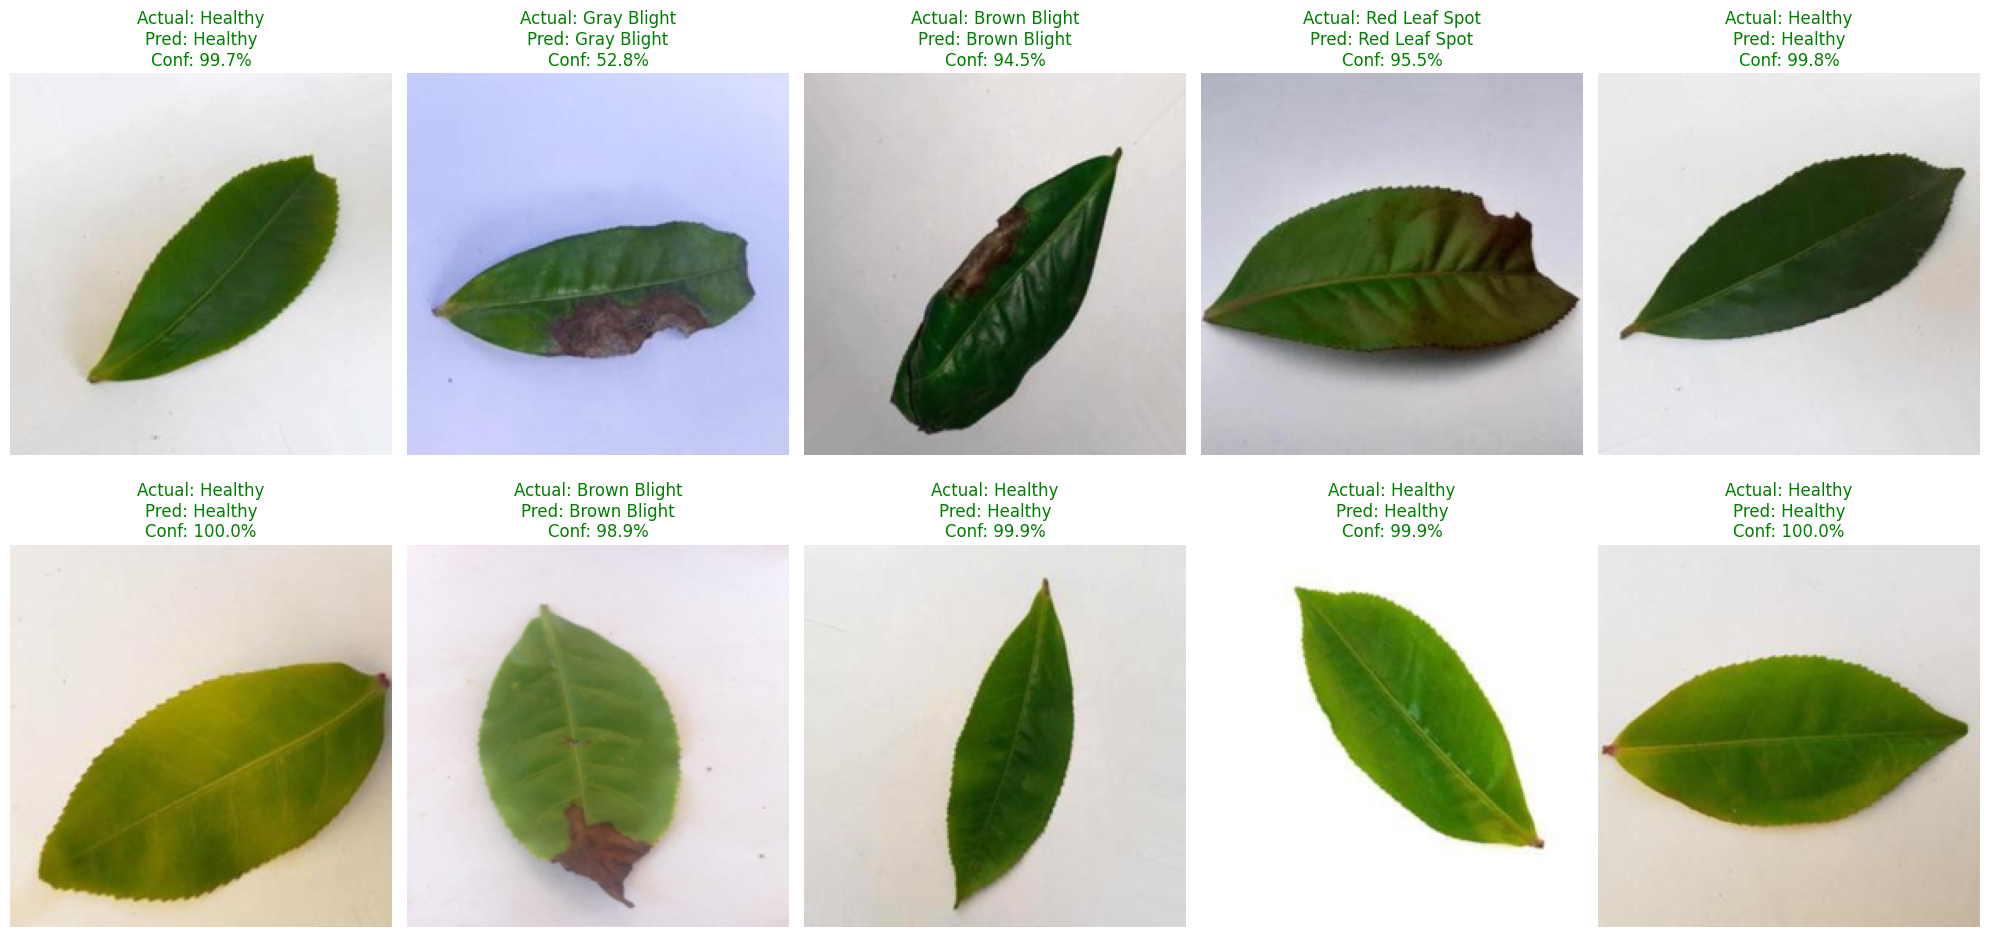

In [ ]:
# 4. Visualize Random Samples from Test Set
plt.figure(figsize=(20, 10))

# Pick 10 random indices from the test set
indices = np.random.choice(len(test_generator.filenames), 10, replace=False)

for i, idx in enumerate(indices):
    img_path = os.path.join('/content/classification_dataset/test', test_generator.filenames[idx])
    img = Image.open(img_path).resize(IMG_SIZE)

    actual_label = class_labels[true_classes[idx]]
    predicted_label = class_labels[pred_classes[idx]]
    confidence = preds[idx][pred_classes[idx]] * 100

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    color = 'green' if actual_label == predicted_label else 'red'
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence:.1f}%", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import zipfile
import os

# 1. Save the training history plot to a file
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.savefig('cnn_training_history.png')
plt.close()

# 2. Save the confusion matrix plot to a file
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cnn_confusion_matrix.png')
plt.close()

# 3. Zip the model and the results
files_to_zip = ['best_tea_disease_cnn.h5', 'cnn_training_history.png', 'cnn_confusion_matrix.png']
zip_filename = 'tea_leaf_cnn_results.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print(f'Successfully created {zip_filename}')

Successfully created tea_leaf_cnn_results.zip


In [ ]:
from google.colab import files
files.download('tea_leaf_cnn_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Inference Script for Saved CNN Model
Use this code to predict the disease on a single new image.

Testing on: /content/classification_dataset/test/Red Leaf Spot/20211227_155737_jpg.rf.f89dfeb030365f46bb0393e4f6281e90.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step


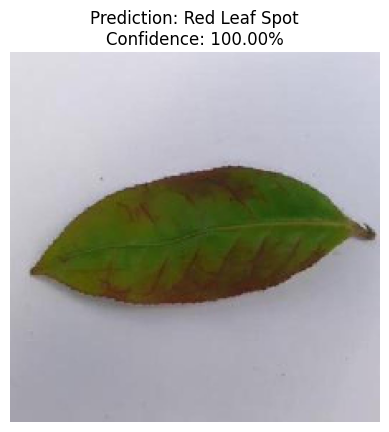

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Load the trained model
model_path = 'best_tea_disease_cnn.h5'
loaded_model = tf.keras.models.load_model(model_path)

# 2. Define class names (must match the training order)
class_names = ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']

def predict_tea_disease(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Run prediction
    predictions = loaded_model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx] * 100

    # Display result
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return class_names[class_idx], confidence

# 3. Test on a random image from the test set
import glob
import random

test_sample_path = random.choice(glob.glob('/content/classification_dataset/test/*/*.jpg'))
print(f"Testing on: {test_sample_path}")
label, conf = predict_tea_disease(test_sample_path)

### Standalone Inference Script
Copy this code into a `.py` file (e.g., `predict.py`) to run it on any machine where you have saved the `best_tea_disease_cnn.h5` model file.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def run_inference(model_path, image_path):
    """
    Loads a trained Keras model and predicts the class of a single image.
    """
    # 1. Define class names in the exact same order as training
    classes = ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']

    # 2. Load the model
    if not os.path.exists(model_path):
        print(f"Error: Model file {model_path} not found.")
        return

    model = tf.keras.models.load_model(model_path)

    # 3. Preprocess the image
    # Target size must be 224x224 as used during CNN training
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # Add batch dimension and rescale (divide by 255 as done in ImageDataGenerator)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 4. Predict
    predictions = model.predict(img_array, verbose=0)
    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx] * 100

    print(f"\n--- Prediction Result ---")
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Result: {classes[class_idx]}")
    print(f"Confidence: {confidence:.2f}%")

if __name__ == "__main__":
    # Change these paths for your local machine
    MY_MODEL = 'best_tea_disease_cnn.h5'
    MY_IMAGE = 'path_to_your_test_image.jpg'

    # Only run if the user has updated the path
    if os.path.exists(MY_IMAGE):
        run_inference(MY_MODEL, MY_IMAGE)
    else:
        print("Please provide a valid path to an image file in the 'MY_IMAGE' variable.")

Please provide a valid path to an image file in the 'MY_IMAGE' variable.


In [ ]:
# Create the standalone .py file
standalone_script = """
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import sys

def run_inference(model_path, image_path):
    # Define class names
    classes = ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']

    if not os.path.exists(model_path):
        print(f"Error: Model file {model_path} not found.")
        return

    # Load model
    model = tf.keras.models.load_model(model_path)

    # Preprocess image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    predictions = model.predict(img_array, verbose=0)
    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx] * 100

    print(f"\\n--- Prediction Result ---")
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Result: {classes[class_idx]}")
    print(f"Confidence: {confidence:.2f}%")

if __name__ == '__main__':
    if len(sys.argv) < 3:
        print("Usage: python predict.py <model_path> <image_path>")
    else:
        run_inference(sys.argv[1], sys.argv[2])
"""

with open('predict.py', 'w') as f:
    f.write(standalone_script.strip())

from google.colab import files
files.download('predict.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    plots=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, f

In [ ]:
import yaml

yaml_path = '/content/dataset/data.yaml'
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config.get('names', [])
    num_classes = data_config.get('nc', 0)
    print(f'Classes found in YAML: {class_names}')
    print(f'Number of classes: {num_classes}')
else:
    print('data.yaml not found. Please verify the extraction path.')

Classes found in YAML: ['Algal Leaf Spot', 'Brown Blight', 'Gray Blight', 'Healthy', 'Helopeltis', 'Red Leaf Spot']
Number of classes: 6


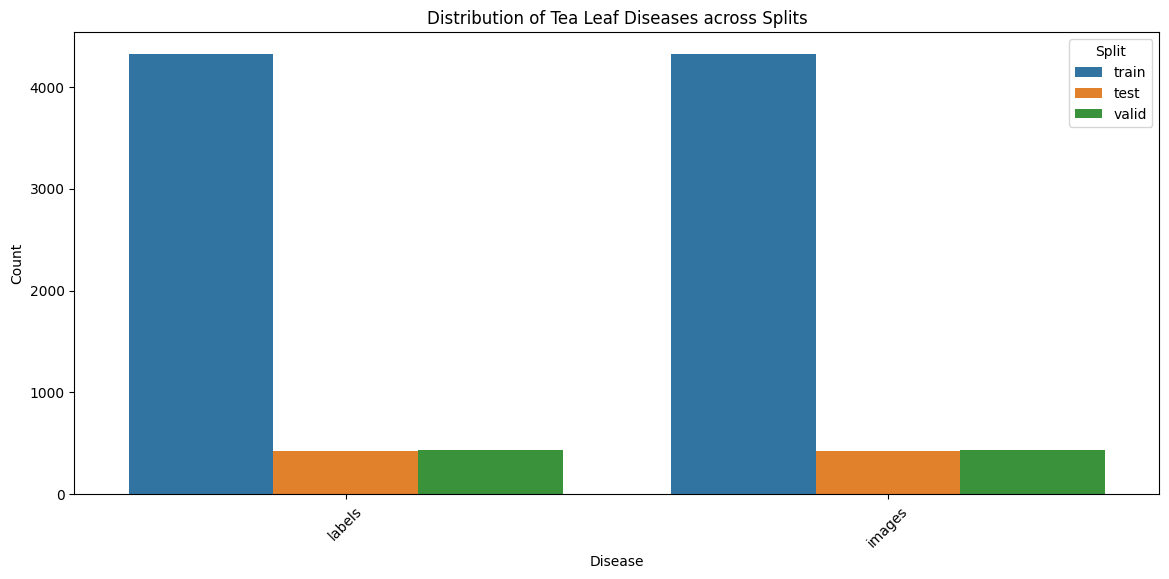

Split,test,train,valid
Disease,,,
images,428,4322,430
labels,428,4322,430


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

def get_distribution(path):
    data = []
    for split in ['train', 'test', 'valid']:
        split_path = os.path.join(path, split)
        if os.path.exists(split_path):
            for disease in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease)
                if os.path.isdir(disease_path):
                    count = len(os.listdir(disease_path))
                    data.append({'Split': split, 'Disease': disease, 'Count': count})
    return pd.DataFrame(data)

dist_df = get_distribution(final_extract_path)

# Visualize distribution
plt.figure(figsize=(14, 6))
sns.barplot(data=dist_df, x='Disease', y='Count', hue='Split')
plt.title('Distribution of Tea Leaf Diseases across Splits')
plt.xticks(rotation=45)
plt.show()

display(dist_df.pivot(index='Disease', columns='Split', values='Count').fillna(0))

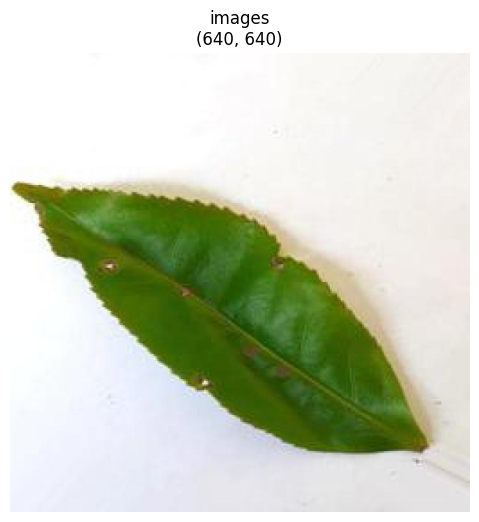

In [ ]:
def plot_samples(base_path, split='train'):
    diseases = sorted([d for d in os.listdir(os.path.join(base_path, split)) if os.path.isdir(os.path.join(base_path, split, d))])
    plt.figure(figsize=(20, 10))
    for i, disease in enumerate(diseases):
        disease_dir = os.path.join(base_path, split, disease)
        img_files = [f for f in os.listdir(disease_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if img_files:
            img_path = os.path.join(disease_dir, random.choice(img_files))
            img = Image.open(img_path)
            plt.subplot(2, 4, i + 1)
            plt.imshow(img)
            plt.title(f"{disease}\n{img.size}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_samples(final_extract_path)

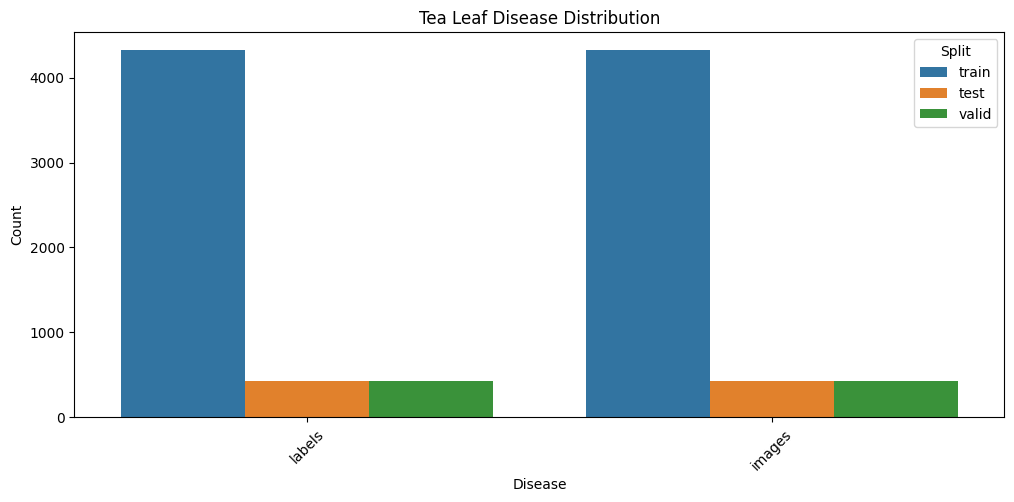

Split,test,train,valid
Disease,,,
images,428,4322,430
labels,428,4322,430


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

def get_distribution(path):
    data = []
    for split in ['train', 'test', 'valid']:
        split_path = os.path.join(path, split)
        if os.path.exists(split_path):
            for disease in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease)
                if os.path.isdir(disease_path):
                    count = len(os.listdir(disease_path))
                    data.append({'Split': split, 'Disease': disease, 'Count': count})
    return pd.DataFrame(data)

dist_df = get_distribution(final_extract_path)

# Visualize distribution
plt.figure(figsize=(12, 5))
sns.barplot(data=dist_df, x='Disease', y='Count', hue='Split')
plt.title('Tea Leaf Disease Distribution')
plt.xticks(rotation=45)
plt.show()

display(dist_df.pivot(index='Disease', columns='Split', values='Count').fillna(0))

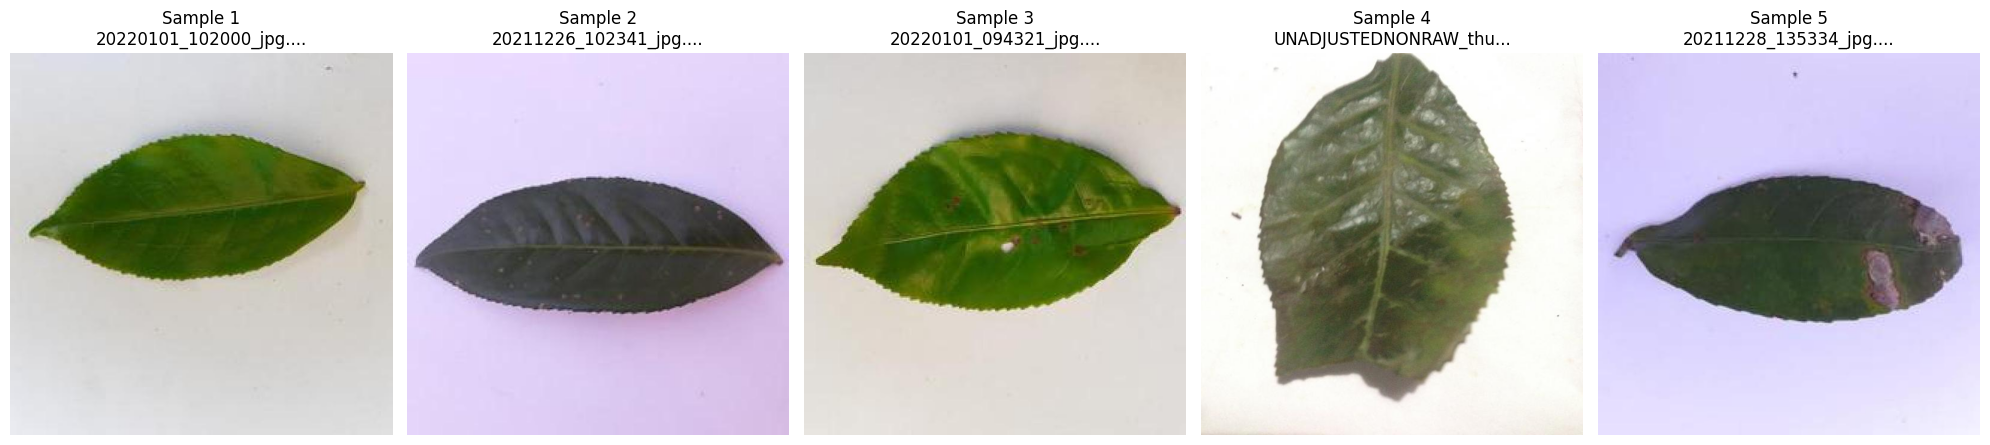

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_random_samples(base_path, split='train', num_samples=5):
    # The dataset uses YOLO format where images are in an 'images' subfolder
    image_dir = os.path.join(base_path, split, 'images')

    if not os.path.exists(image_dir):
        print(f"Directory not found: {image_dir}")
        return

    # Filter to only include actual image files
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    img_files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)]

    if not img_files:
        print(f"No images found in {image_dir}")
        return

    random_files = random.sample(img_files, min(num_samples, len(img_files)))

    plt.figure(figsize=(20, 5))
    for i, img_name in enumerate(random_files):
        img_path = os.path.join(image_dir, img_name)
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Sample {i+1}\n{img_name[:20]}...")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_random_samples(final_extract_path)

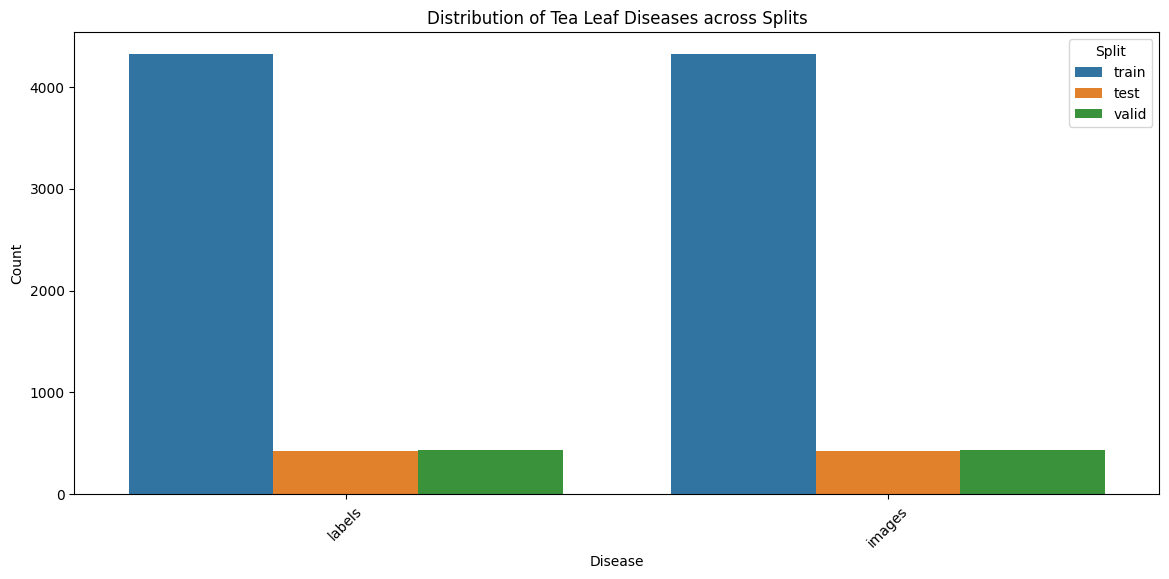

Split,test,train,valid
Disease,,,
images,428,4322,430
labels,428,4322,430


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_distribution(path):
    data = []
    for split in ['train', 'test', 'valid']:
        split_path = os.path.join(path, split)
        if os.path.exists(split_path):
            for disease in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease)
                if os.path.isdir(disease_path):
                    count = len(os.listdir(disease_path))
                    data.append({'Split': split, 'Disease': disease, 'Count': count})
    return pd.DataFrame(data)

dist_df = get_distribution(final_extract_path)

# Visualize distribution
plt.figure(figsize=(14, 6))
sns.barplot(data=dist_df, x='Disease', y='Count', hue='Split')
plt.title('Distribution of Tea Leaf Diseases across Splits')
plt.xticks(rotation=45)
plt.show()

display(dist_df.pivot(index='Disease', columns='Split', values='Count'))

In [ ]:
inner_zip = '/content/tea_leaf_data/Tea leaf disease Dataset/Tea Leaf Diseases.zip'
final_extract_path = '/content/dataset'

if os.path.exists(inner_zip):
    with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
        zip_ref.extractall(final_extract_path)
    print(f'Final dataset extracted to {final_extract_path}')

    # Verify the contents of the final folder
    if os.path.exists(final_extract_path):
        classes = [d for d in os.listdir(final_extract_path) if os.path.isdir(os.path.join(final_extract_path, d))]
        print(f'Found {len(classes)} classes: {classes}')
else:
    print('Inner zip file not found. Please check the path.')

Final dataset extracted to /content/dataset
Found 3 classes: ['train', 'test', 'valid']


In [ ]:
inner_zip = '/content/tea_leaf_data/Tea leaf disease Dataset/Tea Leaf Diseases.zip'
final_extract_path = '/content/dataset'

if os.path.exists(inner_zip):
    with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
        zip_ref.extractall(final_extract_path)
    print(f'Final dataset extracted to {final_extract_path}')

    # Verify the contents of the final folder
    classes = [d for d in os.listdir(final_extract_path) if os.path.isdir(os.path.join(final_extract_path, d))]
    print(f'Found {len(classes)} classes: {classes}')
else:
    print('Inner zip file not found.')

Final dataset extracted to /content/dataset
Found 3 classes: ['train', 'test', 'valid']
